### DATA EXPLORATION

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date, datetime

In [5]:
# # create a duckdb with the df as table "theme_park_raw'
conn = duckdb.connect(database='../../data/themepark.duckdb')

# Creation of duckdb
# conn.execute(""'CREATE TABLE theme_park_raw AS
# SELECT *
# FROM 'data.parquet';
# """)

In [6]:
theme_park_raw = conn.execute("""
    SELECT *
    FROM theme_park_raw
    LIMIT 10
""").fetchdf()

theme_park_raw

,NodeNo,FiscalDate,TranDate,CompanyID,Abbr,Name,Environment,AccountID,Qty,Amount,...,OriginalAmount,JnlDetailID,CatCode17Desc1,Last_In_Unit_Cost,Average_Unit_Cost,CatCode18Desc1,TranNo,ReceiptNo,SurveyID,Race
0,91,2023-11-11 16:00:00,2023-11-12 08:16:30,1,None,None,1,000110110101,1,0.00,...,0.00,185703107,Revenue,NaN,NaN,Group Functions-Entrance,84018,24191,<NA>,None
1,26,2024-12-21 16:00:00,2024-12-22 06:54:31,1,None,None,1,000110120204,1,25.00,...,25.00,221079374,Revenue,NaN,NaN,Lockers,464236,397165,<NA>,None
2,231,2024-07-11 16:00:00,2024-07-12 05:47:53,1,None,None,1,000153200802,0,0.00,...,0.00,199289222,None,NaN,NaN,None,70529,72634,1,Malaysia
3,201,2025-01-04 16:00:00,2025-01-05 05:23:14,10,None,None,1,001053200104,0,6.50,...,6.50,222793285,None,NaN,NaN,None,119680,213500,<NA>,None
4,365,2024-04-19 16:00:00,2024-04-20 08:19:11,10,None,None,1,001010210101,1,6.60,...,6.60,194274857,Revenue,NaN,NaN,F&B Kiosk,45754,253626,<NA>,None
5,10,2023-03-21 16:00:00,2023-03-22 03:24:55,1,None,None,1,000153200101,0,10.00,...,10.00,174581567,None,NaN,NaN,None,268628,189054,<NA>,None
6,18,2022-10-26 16:00:00,2022-10-27 04:51:45,1,None,None,2,000110220101,2,8.50,...,8.50,97918093,Revenue,0.4917,0.5488,F&B Kiosk,130650,96960,<NA>,None
7,30,2024-04-09 16:00:00,2024-04-10 12:19:29,1,None,None,2,000112000300,0,0.68,...,0.68,116857935,None,NaN,NaN,None,94651,48351,<NA>,None
8,6,2023-04-08 16:00:00,2023-04-09 01:29:29,1,None,None,1,000110110401,1,0.00,...,0.00,175267134,None,NaN,NaN,None,245354,189338,<NA>,None
9,44,2022-11-14 16:00:00,2022-11-15 11:37:48,1,None,None,2,000110132203,1,20.00,...,20.00,98529220,Revenue,NaN,NaN,Lockers,240460,168860,<NA>,None


In [5]:
# Table dimension
# Row count
row_count = conn.execute("SELECT COUNT(*) FROM theme_park_raw").fetchone()
print("Total Rows:", row_count)

col_count = conn.execute("""SELECT COUNT(*) FROM information_schema.columns
        WHERE table_name = 'theme_park_raw';
        """).fetchone()
print("Total Cols:", col_count)

Total Rows: (44037386,)
Total Cols: (122,)


In [6]:
# Table Descriptive Statistics
summarize_revenue_grouping_park = conn.execute("""SUMMARIZE theme_park_raw""").df()
summarize_revenue_grouping_park


,column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
0,NodeNo,INTEGER,0,10199,378,322.05889474699376,1393.965025278869,14,53,232,44037386,0.00
1,FiscalDate,TIMESTAMP,2013-08-18 16:00:00,2025-10-09 16:00:00,2377,2023-12-13 04:45:06.071682,None,2023-02-27 13:16:24.249785,2024-01-07 10:48:01.483722,2024-11-02 08:31:06.615822,44037386,0.00
2,TranDate,TIMESTAMP,2013-08-19 09:04:50.177,2025-10-09 16:54:00,11477172,2023-12-13 19:30:46.38837,None,2023-02-28 01:19:11.758141,2024-01-09 03:33:50.17724,2024-11-02 09:31:06.560884,44037386,0.00
3,CompanyID,INTEGER,0,10,3,3.401016090723526,3.980508107635427,1,1,10,44037386,3.23
4,Abbr,VARCHAR,,ZENStaf30%,253,None,None,None,None,None,44037386,89.36
...,...,...,...,...,...,...,...,...,...,...,...,...
117,CatCode18Desc1,VARCHAR,,Unclaimed credits / deposit,42,None,None,None,None,None,44037386,52.82
118,TranNo,INTEGER,1,735509,782958,202428.95164698662,160882.16349298874,74606,156829,306032,44037386,8.31
119,ReceiptNo,INTEGER,0,662741,738185,179053.43899616913,146124.71866581228,56751,155261,266539,44037386,8.31
120,SurveyID,INTEGER,1,2,2,1.0000035043705957,0.0018719933123297946,1,1,1,44037386,87.69



The Environment field in the raw data table indicates which entity the data belongs to.
1. Lagoon
2. LWOT

Revenue_Grouping field
- If has value - entry to the park facility, e.g., hotel, park, etc
- If no value - misc transactions within the park facility, e.g., food, locker, rental, etc

Visitorship - revenue grouping with val

In [206]:
# entrance revenue grouping by park 2024
print("visitor revenue grouping")
visitor_revenue_grouping_park = conn.execute("""
SELECT
    TRIM(Park) as Grouping,
    CASE
        WHEN Environment = 1 THEN 'Sunway Lagoon'
        WHEN Environment = 2 THEN 'Lost World'
    END AS park,
    SUM(OriginalAmount * Complete_QTY) AS revenue,
    SUM(Complete_QTY) AS visitor
FROM theme_park_raw
WHERE Environment IN (1, 2) 
    AND Grouping IS NOT NULL
    AND TranDate >= TIMESTAMP '2023-12-31 16:00:00'
GROUP BY
    Grouping,
    Environment
ORDER BY
    park,
    revenue
""").df()
visitor_revenue_grouping_park


visitor revenue grouping


,Grouping,park,revenue,visitor
0,Membership,Lost World,0.000000e+00,465664.000000
1,FOC / Complimentary,Lost World,0.000000e+00,6331.000000
2,Inter-company/Staff,Lost World,2.413616e+05,2913.000000
3,Tours/Hotels/Presold,Lost World,6.572624e+05,402752.250000
4,Group Function,Lost World,4.949936e+06,67973.000000
5,Hotspring,Lost World,4.956299e+06,259294.000000
6,Water Park,Lost World,9.785729e+06,110869.000000
7,Walk in,Sunway Lagoon,0.000000e+00,120.000000
8,Walk in - Online,Sunway Lagoon,0.000000e+00,6934.000000
9,B2C Online,Sunway Lagoon,0.000000e+00,27250.000000


In [207]:
# revenue / visitor percentage over total
visitor_revenue_grouping_park["revenue_pct"] = (
    visitor_revenue_grouping_park["revenue"]
    / visitor_revenue_grouping_park.groupby("park")["revenue"].transform("sum")
    * 100
).round(2)

visitor_revenue_grouping_park["visitor_pct"] = (
    visitor_revenue_grouping_park["visitor"]
    / visitor_revenue_grouping_park.groupby("park")["visitor"].transform("sum")
    * 100
).round(2)

visitor_revenue_grouping_park

,Grouping,park,revenue,visitor,revenue_pct,visitor_pct
0,Membership,Lost World,0.000000e+00,465664.000000,0.00,35.39
1,FOC / Complimentary,Lost World,0.000000e+00,6331.000000,0.00,0.48
2,Inter-company/Staff,Lost World,2.413616e+05,2913.000000,1.17,0.22
3,Tours/Hotels/Presold,Lost World,6.572624e+05,402752.250000,3.19,30.61
4,Group Function,Lost World,4.949936e+06,67973.000000,24.04,5.17
5,Hotspring,Lost World,4.956299e+06,259294.000000,24.07,19.71
6,Water Park,Lost World,9.785729e+06,110869.000000,47.53,8.43
7,Walk in,Sunway Lagoon,0.000000e+00,120.000000,0.00,0.01
8,Walk in - Online,Sunway Lagoon,0.000000e+00,6934.000000,0.00,0.40
9,B2C Online,Sunway Lagoon,0.000000e+00,27250.000000,0.00,1.56


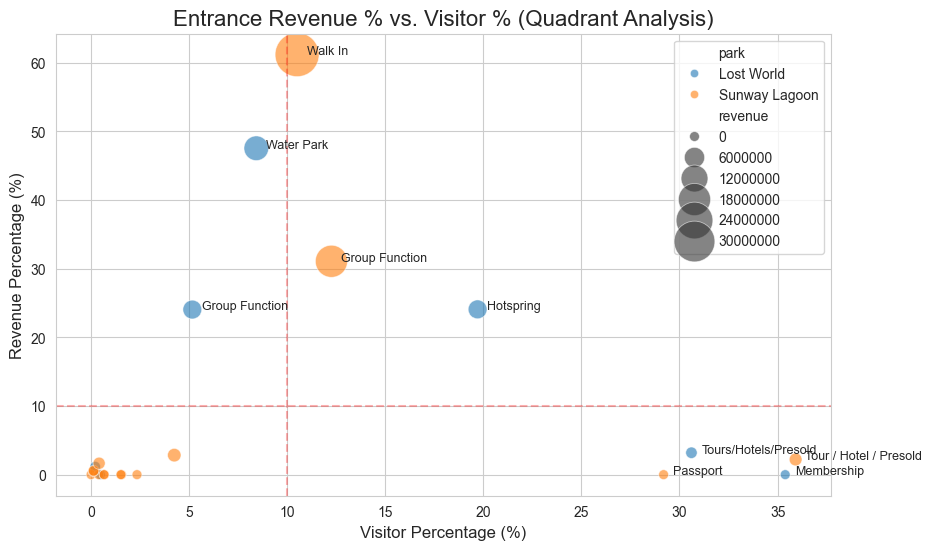

In [208]:
# Chart 1: Revenue vs Visitor Percentage (Scatter Plot / Quadrant Analysis)
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
scatter = sns.scatterplot(data=visitor_revenue_grouping_park, x='visitor_pct', y='revenue_pct', hue='park', size='revenue', sizes=(50, 1000), alpha=0.6)

# Annotate key outliers (High Revenue or High Visitor)
for i in range(visitor_revenue_grouping_park.shape[0]):
    if visitor_revenue_grouping_park.revenue_pct[i] > 10 or visitor_revenue_grouping_park.visitor_pct[i] > 4.5:
        plt.text(visitor_revenue_grouping_park.visitor_pct[i]+0.5, visitor_revenue_grouping_park.revenue_pct[i], visitor_revenue_grouping_park.Grouping[i], fontsize=9)

plt.title('Entrance Revenue % vs. Visitor % (Quadrant Analysis)', fontsize=16)
plt.xlabel('Visitor Percentage (%)', fontsize=12)
plt.ylabel('Revenue Percentage (%)', fontsize=12)
plt.axvline(10, color='red', linestyle='--', alpha=0.3)
plt.axhline(10, color='red', linestyle='--', alpha=0.3)
plt.show()



In [ ]:
## useful cols
"""
NodeID, NodeName | FiscalDate, TranDate | Abbr, Name | Environment | 
AccountID, AccountName | Qty, Amount | AgencyName, AgencyDescription, UserID, UserName |
Category, SubCat | UserCode1, UserCode2, UserCode3, CodeDescr, OrderDescription |
OrderID, InvoiceID, OrderQty, IssuedQty, OrderAmount, OrderTOtal, DiscountAmount, TaxAmount
"""

"""
1. visitorship trend
    - by park
    - granularity (hourly/daily/weekly/monthly)
2. revenue trend
    - granularity (hourly / daily / weekly/ monthly)
    - by park
    - by revenue grouping
    - per visitor

Question:
- is the revenue growing because of more visitors or higher spend in other area?
- which park is carrying growth?    

Monetization drivers
1. spend per visitor (average revenue per visitor)
    ARPV = total revenue / total visitors

"""

In [ ]:
# create a holidays table based on the holidays in theme_park_raw
# conn.execute("""
#     DROP TABLE IF EXISTS holidays;
#     CREATE TABLE holidays AS
#     SELECT
#         date_trunc('day', TranDate) AS holiday_date,
#         -- If multiple names exist for one date, just pick one. MAX() works well.
#         MAX(HolidayName1) AS holiday_name
#     FROM theme_park_raw
#     WHERE HolidayName1 IS NOT NULL
#     GROUP BY 1; -- Group by holiday_date
# """)

holidays = conn.execute("""
    SELECT *
    FROM holidays
    ORDER BY holiday_date ASC
""").fetchdf()

holidays

,holiday_date,holiday_name
0,2013-08-19,
1,2013-09-13,
2,2013-09-26,
3,2013-09-27,
4,2013-10-24,
...,...,...
2772,2025-10-05,
2773,2025-10-06,
2774,2025-10-07,
2775,2025-10-08,


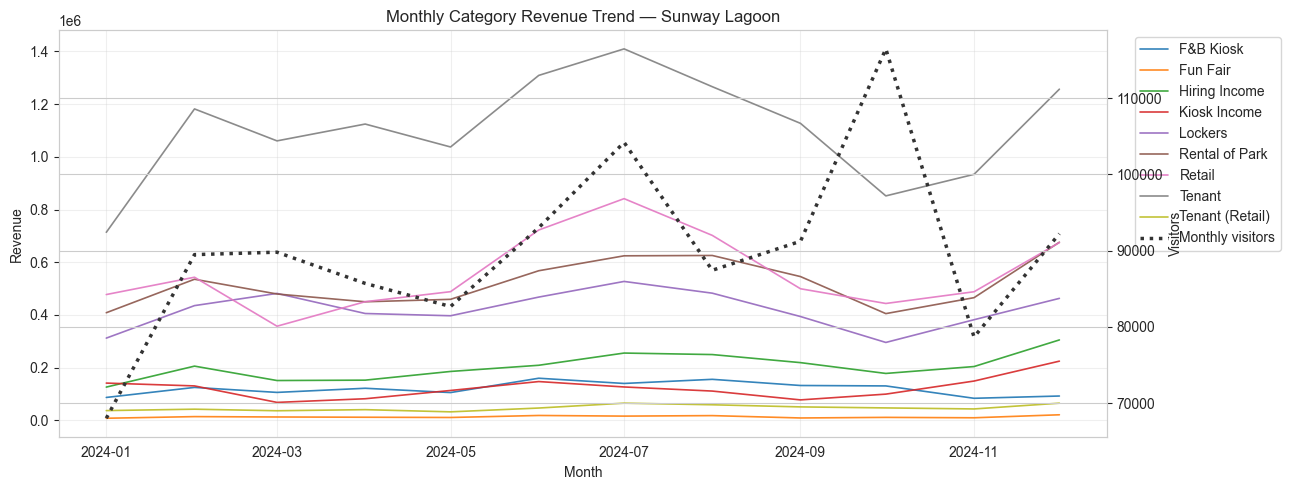

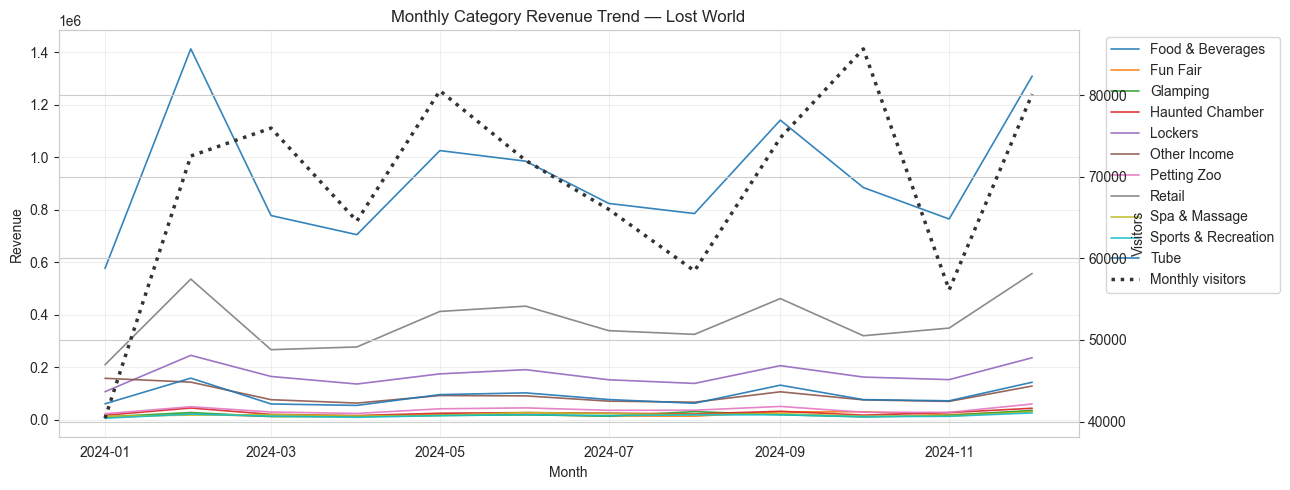

In [209]:
# monthly category revenue trend (same category filter as monthly_category_txns)
category_filter = [
    'Retail', 'Petting Zoo', 'Spa & Massage', 'Other Income', 'Fun Fair',
    'Food & Beverages', 'Lockers', 'Glamping', 'Sports & Recreation',
    'Haunted Chamber', 'Tube', 'F&B Kiosk', 'Fun Fair', 'Retail',
    'Kiosk Income', 'Lockers', 'Hiring Income', 'Tenant (Retail)',
    'Tenant', 'Rental of Park'
]

category_filter_sql = ', '.join([f"'{c}'" for c in category_filter])

query = f"""
WITH monthly_entries AS (
    SELECT
        DATE_TRUNC('month', TranDate + INTERVAL '8 hours') AS month,
        Environment,
        SUM(Complete_QTY) AS visitors
    FROM theme_park_raw
    WHERE Environment IN (1, 2)
      AND TranDate >= TIMESTAMP '2023-12-31 16:00:00'
      AND TranDate <  TIMESTAMP '2024-12-31 16:00:00'
      AND Park IS NOT NULL
    GROUP BY 1, 2
),
monthly_category_rev AS (
    SELECT
        DATE_TRUNC('month', TranDate + INTERVAL '8 hours') AS month,
        Environment,
        TRIM(Category_Name) AS category_name,
        SUM(OriginalAmount) AS revenue
    FROM theme_park_raw
    WHERE Environment IN (1, 2)
      AND TranDate >= TIMESTAMP '2023-12-31 16:00:00'
      AND TranDate <  TIMESTAMP '2024-12-31 16:00:00'
      AND Category_Name IN ({category_filter_sql})
    GROUP BY 1, 2, 3
)
SELECT
    e.month,
    CASE
        WHEN e.Environment = 1 THEN 'Sunway Lagoon'
        WHEN e.Environment = 2 THEN 'Lost World'
    END AS park,
    e.visitors,
    c.category_name,
    COALESCE(c.revenue, 0) AS revenue
FROM monthly_entries e
LEFT JOIN monthly_category_rev c
  ON e.month = c.month
 AND e.Environment = c.Environment
ORDER BY e.month, park, c.category_name;
"""
category_monthly_revenue = conn.execute(query).df()

def plot_monthly_category_revenue(park_name, data):
    sub = data[data["park"] == park_name].sort_values("month")
    visitors = data[data["park"] == park_name].sort_values("month")

    fig, ax1 = plt.subplots(figsize=(13, 5))

    # ---- Category revenue lines ----
    for cat, s in sub.groupby("category_name"):
        ax1.plot(
            s["month"],
            s["revenue"],
            linewidth=1.2,
            alpha=0.9,
            label=cat
        )

    ax1.set_title(f"Monthly Category Revenue Trend — {park_name}")
    ax1.set_xlabel("Month")
    ax1.set_ylabel("Revenue")
    ax1.grid(True, alpha=0.3)

    # ---- Monthly visitors (dotted line, secondary axis) ----
    ax2 = ax1.twinx()
    ax2.plot(
        visitors["month"],
        visitors["visitors"],
        linestyle=":",
        linewidth=2.5,
        color="#333333",
        label="Monthly visitors"
    )
    ax2.set_ylabel("Visitors")

    # ---- Combine legends ----
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(
        h1 + h2,
        l1 + l2,
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()

plot_monthly_category_revenue('Sunway Lagoon', category_monthly_revenue)
plot_monthly_category_revenue('Lost World', category_monthly_revenue)


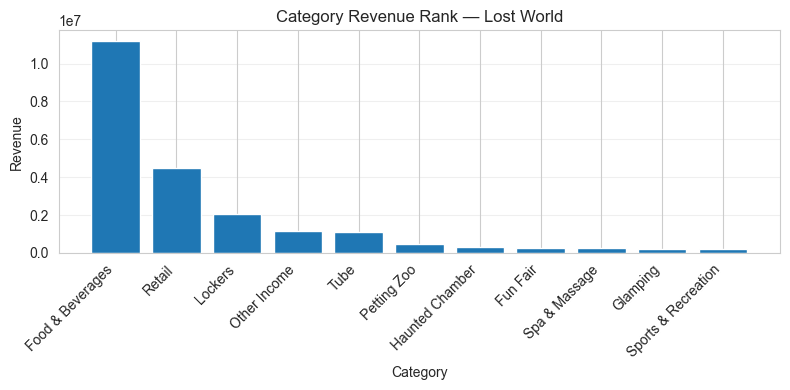

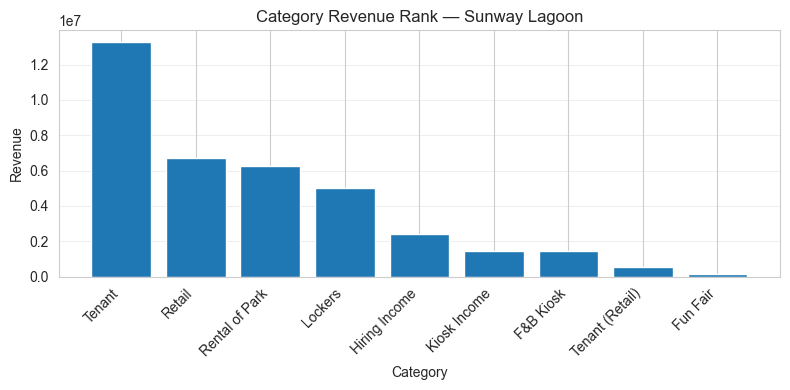

In [210]:
# rank of category revenue
query = f"""
SELECT
    CASE
        WHEN Environment = 1 THEN 'Sunway Lagoon'
        WHEN Environment = 2 THEN 'Lost World'
    END AS park,
    Category_Name,
    SUM(OriginalAmount) AS revenue
FROM theme_park_raw
WHERE TranDate >= TIMESTAMP '2023-12-31 16:00:00'
    AND TranDate <  TIMESTAMP '2024-12-31 16:00:00'
    AND Category_Name IN ({category_filter_sql})
GROUP BY Environment, Category_Name
ORDER BY park, Category_Name
"""
category_revenue_park = conn.execute(query).df()


for park, df_park in category_revenue_park.groupby("park"):
    df_sorted = df_park.sort_values("revenue", ascending=False)

    plt.figure(figsize=(8, 4))
    plt.bar(df_sorted["Category_Name"], df_sorted["revenue"])
    plt.title(f"Category Revenue Rank — {park}")
    plt.xlabel("Category")
    plt.ylabel("Revenue")
    plt.xticks(rotation=45, ha="right")
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()



In [211]:
daily_visitors = conn.execute("""
WITH daily AS (
    SELECT
        CAST(TranDate + INTERVAL '8 hours' AS DATE) AS visit_date,
        CASE
            WHEN Environment = 1 THEN 'Sunway Lagoon'
            WHEN Environment = 2 THEN 'Lost World'
        END AS park,
        CAST(SUM(Complete_QTY) AS INT) AS visitors,
        CASE
            WHEN STRFTIME(CAST(TranDate + INTERVAL '8 hours' AS DATE), '%w') IN ('0','6') THEN 1 ELSE 0
        END AS is_weekend,
        CASE
            WHEN STRFTIME(CAST(TranDate + INTERVAL '8 hours' AS DATE), '%w') = '2' THEN 1 ELSE 0
        END AS is_tuesday
    FROM theme_park_raw
    WHERE Environment IN (1, 2)
      AND TranDate >= TIMESTAMP '2024-12-31 16:00:00'
      AND TranDate <  TIMESTAMP '2025-12-31 16:00:00'
    GROUP BY
        visit_date,
        Environment
),
holiday_dim AS (
    SELECT
        holiday_date,
        TRIM(holiday_name) AS holiday_name
    FROM holidays
)
SELECT
    d.visit_date,
    d.park,
    d.visitors,
    d.is_weekend,
    CASE
        WHEN h.holiday_name IS NOT NULL AND h.holiday_name <> '' THEN 1 ELSE 0
    END AS is_holiday,
    h.holiday_name,
    d.is_tuesday,
    CASE
        WHEN d.is_tuesday = 1
         AND (h.holiday_name IS NULL OR h.holiday_name = '')
        THEN 1 ELSE 0
    END AS is_closed_day
FROM daily d
LEFT JOIN holiday_dim h
  ON d.visit_date = h.holiday_date
ORDER BY
    d.visit_date,
    d.park;
""").df()

daily_visitors


,visit_date,park,visitors,is_weekend,is_holiday,holiday_name,is_tuesday,is_closed_day
0,2025-01-01,Lost World,8908,0,1,New Year Day,0,0
1,2025-01-01,Sunway Lagoon,15625,0,1,New Year Day,0,0
2,2025-01-02,Lost World,4965,0,0,,0,0
3,2025-01-02,Sunway Lagoon,9002,0,0,,0,0
4,2025-01-03,Lost World,6484,0,0,,0,0
...,...,...,...,...,...,...,...,...
561,2025-10-08,Sunway Lagoon,6350,0,0,,0,0
562,2025-10-09,Lost World,6185,0,0,,0,0
563,2025-10-09,Sunway Lagoon,4289,0,0,,0,0
564,2025-10-10,Lost World,7,0,0,None,0,0


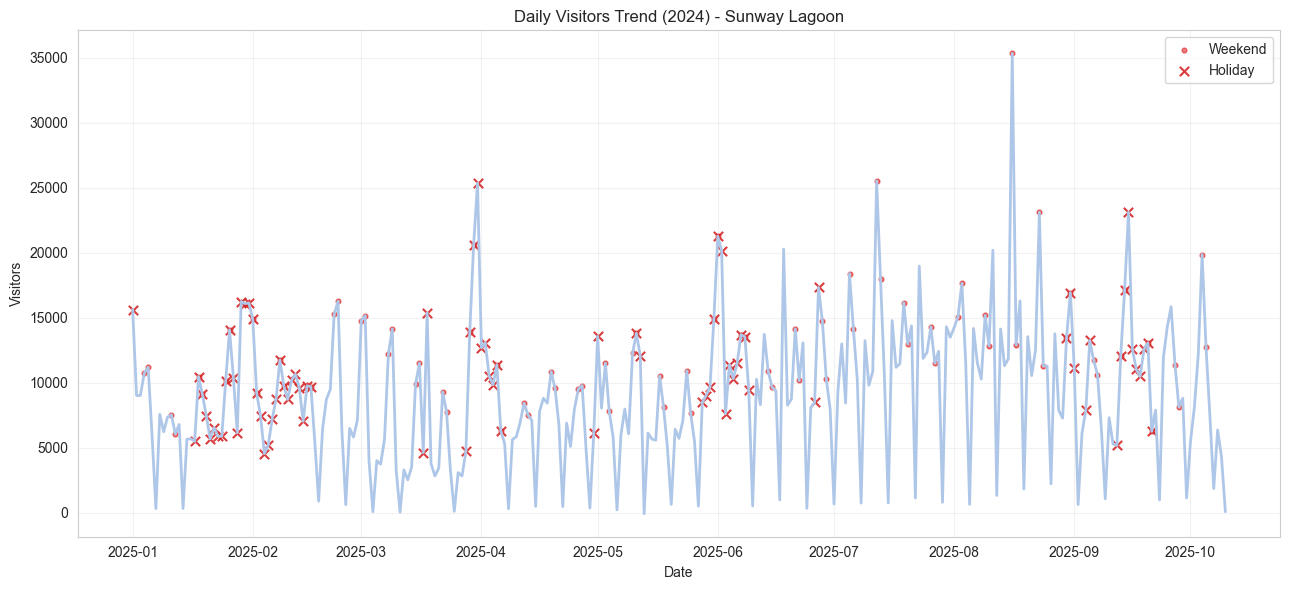

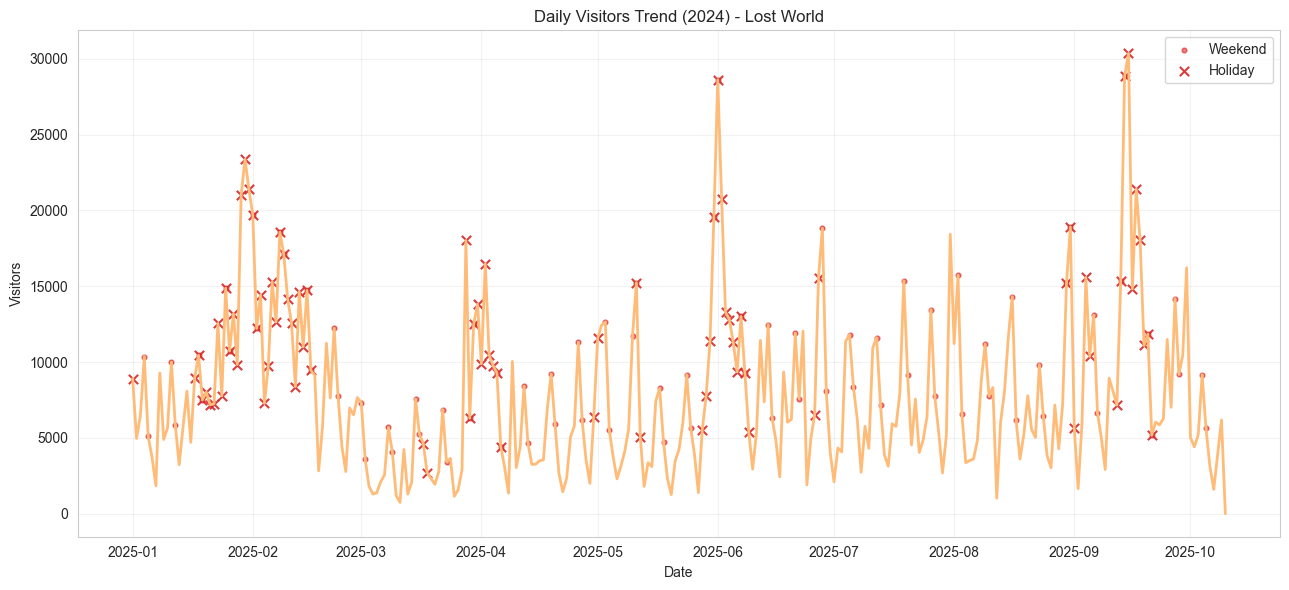

In [212]:
import matplotlib.pyplot as plt

df = daily_visitors.copy()
df["visit_date"] = df["visit_date"].astype("datetime64[ns]")

def plot_park(park_name: str):
    sub = df[df["park"] == park_name].copy()

    plt.figure(figsize=(13, 6))

    line_colors = {
        "Sunway Lagoon": "#aec7e8",  # light blue
        "Lost World": "#ffbb78"      # light orange
    }

    # ---- Trend lines (open days only) ----
    plt.plot(
        sub["visit_date"],
        sub["visitors"],   # change to sub["visitors"] if you want raw daily
        linewidth=2,
        color=line_colors.get(park_name, "#cccccc"),
    )

    # ---- Weekend markers (once; open days only) ----
    weekends = sub[sub["is_weekend"] == 1].drop_duplicates(["visit_date"])
    plt.scatter(
        weekends["visit_date"],
        weekends["visitors"],
        s=12,
        alpha=0.5,
        color="#db0000",
        label="Weekend"
    )

    # ---- Holiday markers (once; open days only) ----
    holidays = sub[sub["is_holiday"] == 1].drop_duplicates(["visit_date"])
    plt.scatter(
        holidays["visit_date"],
        holidays["visitors"],
        s=45,
        marker="x",
        alpha=0.9,
        color="#d62728",
        label="Holiday"
    )

    plt.title(f"Daily Visitors Trend (2024) - {park_name}")
    plt.xlabel("Date")
    plt.ylabel("Visitors")
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_park("Sunway Lagoon")
plot_park("Lost World")

In [213]:
# Attach Rate = percentage of primary product sales that include a secondary, complementary product or service, evaluate cross-selling and upselling to boost revenue from existing customers
# Primary: Themepark Entrance, Secondary: Retail, F&B, etc
# Formula: (Total Num of Transactions in Category X) / (Total Park Entries)

monthly_category_txns = conn.execute("""
WITH monthly_entries AS (
    SELECT
        DATE_TRUNC('month', TranDate + INTERVAL '8 hours') AS month,
        Environment,
        CAST(SUM(Complete_QTY) AS INT) AS visitors
    FROM theme_park_raw
    WHERE Environment IN (1, 2)
      AND TranDate >= TIMESTAMP '2023-12-31 16:00:00'
      AND Park IS NOT NULL
    GROUP BY 1, 2
),
monthly_category_txn AS (
    SELECT
        DATE_TRUNC('month', TranDate + INTERVAL '8 hours') AS month,
        Environment,
        Category_Name as category_name,
        COUNT(*) AS transactions
    FROM theme_park_raw
    WHERE Environment IN (1, 2)
      AND TranDate >= TIMESTAMP '2023-12-31 16:00:00'
      AND Category_Name IN ('Retail','Petting Zoo', 'Spa & Massage', 'Other Income', 'Fun Fair', 'Food & Beverages', 'Lockers', 'Glamping', 'Sports & Recreation', 'Haunted Chamber', 'Tube',
                                'F&B Kiosk', 'Fun Fair', 'Retail', 'Kiosk Income', 'Lockers', 'Hiring Income', 'Tenant (Retail)', 'Tenant', 'Rental of Park')
    GROUP BY 1, 2, category_name
)
SELECT
    e.month,
    CASE
        WHEN e.Environment = 1 THEN 'Sunway Lagoon'
        WHEN e.Environment = 2 THEN 'Lost World'
    END AS park,
    e.visitors AS visitors,
    t.category_name,
    COALESCE(t.transactions, 0) AS transactions,
    COALESCE(t.transactions, 0) * 1.0 / e.visitors AS attach_rate
FROM monthly_entries e
LEFT JOIN monthly_category_txn t
  ON e.month = t.month
 AND e.Environment = t.Environment
ORDER BY e.month, park, category_name;
""").df()
monthly_category_txns

,month,park,visitors,category_name,transactions,attach_rate
0,2024-01-01,Lost World,40405,Food & Beverages,60863,1.506323
1,2024-01-01,Lost World,40405,Fun Fair,895,0.022151
2,2024-01-01,Lost World,40405,Glamping,217,0.005371
3,2024-01-01,Lost World,40405,Haunted Chamber,1746,0.043212
4,2024-01-01,Lost World,40405,Lockers,3329,0.082391
...,...,...,...,...,...,...
435,2025-10-01,Sunway Lagoon,19015,Lockers,2722,0.143150
436,2025-10-01,Sunway Lagoon,19015,Rental of Park,3115,0.163818
437,2025-10-01,Sunway Lagoon,19015,Retail,7510,0.394951
438,2025-10-01,Sunway Lagoon,19015,Tenant,15242,0.801578


In [214]:
monthly_category_txns = monthly_category_txns.sort_values(["park", "category_name", "month"])

monthly_category_txns["visitor_growth_pct"] = (
    monthly_category_txns.groupby("park")["visitors"]
      .pct_change()
)

monthly_category_txns["attach_rate_growth_pct"] = (
    monthly_category_txns.groupby(["park", "category_name"])["attach_rate"]
      .pct_change()
)
monthly_category_txns

,month,park,visitors,category_name,transactions,attach_rate,visitor_growth_pct,attach_rate_growth_pct
0,2024-01-01,Lost World,40405,Food & Beverages,60863,1.506323,NaN,NaN
20,2024-02-01,Lost World,72545,Food & Beverages,153528,2.116314,0.795446,0.404953
40,2024-03-01,Lost World,75961,Food & Beverages,87786,1.155672,0.047088,-0.453922
60,2024-04-01,Lost World,64570,Food & Beverages,78491,1.215595,-0.149959,0.051852
80,2024-05-01,Lost World,80548,Food & Beverages,113174,1.405050,0.247452,0.155854
...,...,...,...,...,...,...,...,...
359,2025-06-01,Sunway Lagoon,84006,Tenant (Retail),1294,0.015404,0.387749,0.332065
379,2025-07-01,Sunway Lagoon,87613,Tenant (Retail),1760,0.020088,0.042937,0.304128
399,2025-08-01,Sunway Lagoon,90670,Tenant (Retail),2003,0.022091,0.034892,0.099697
419,2025-09-01,Sunway Lagoon,72437,Tenant (Retail),1167,0.016111,-0.201092,-0.270722


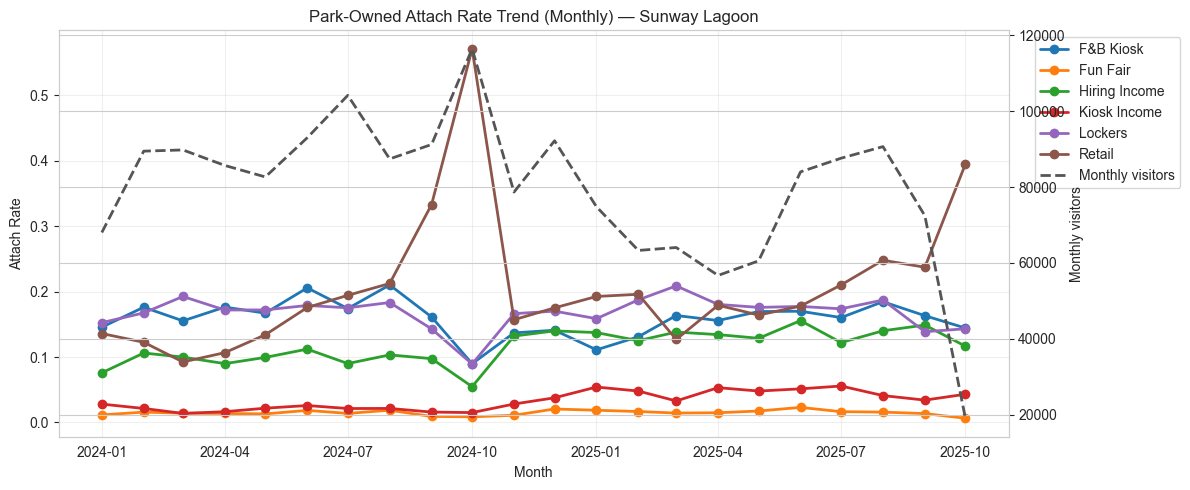

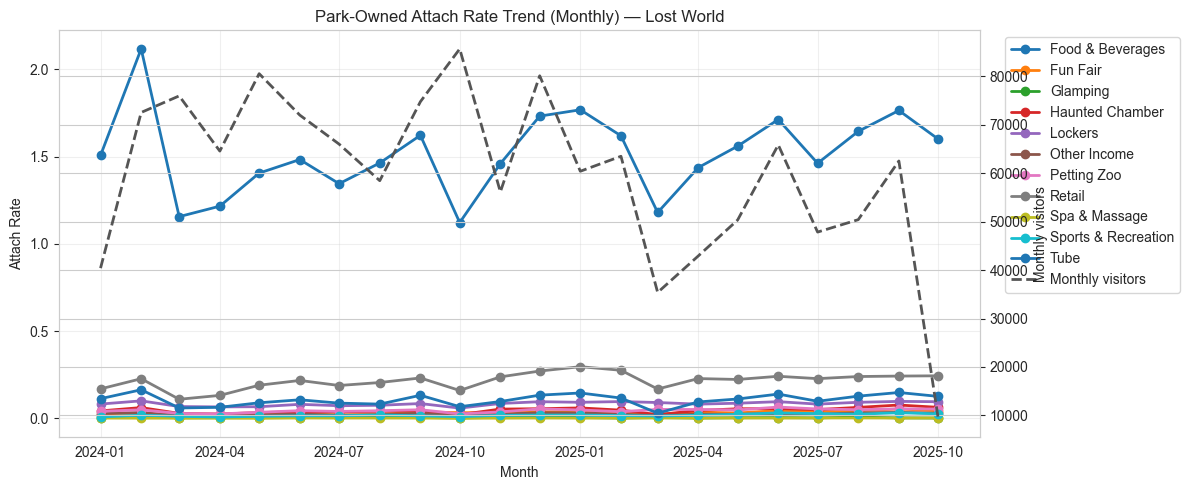

In [215]:
# In Park Revenue (Internal only)
external_categories = ['Tenant (Retail)', 'Tenant', 'Rental of Park']

monthly_category_txns_internal = monthly_category_txns[
    ~monthly_category_txns["category_name"].isin(external_categories)
]

def plot_attach_trend(park_name, data):
    sub = data[data["park"] == park_name].sort_values("month")

    fig, ax1 = plt.subplots(figsize=(12, 5))
    for cat, s in sub.groupby("category_name"):
        plt.plot(s["month"], s["attach_rate"], marker="o", linewidth=2, label=cat)

    ax1.set_title(f"Park-Owned Attach Rate Trend (Monthly) — {park_name}")
    ax1.set_xlabel("Month")
    ax1.set_ylabel("Attach Rate")
    ax1.grid(True, alpha=0.3)
    
    # Monthly visitors (one value per month)
    monthly_visitors = (
        sub[["month", "visitors"]]
        .drop_duplicates("month")
        .sort_values("month")
    )

    ax2 = ax1.twinx()
    ax2.plot(
        monthly_visitors["month"],
        monthly_visitors["visitors"],
        color="#555555",
        linewidth=2,
        linestyle="--",
        label="Monthly visitors"
    )
    ax2.set_ylabel("Monthly visitors")

    # ✅ Combine legends from both axes
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    plt.show()

plot_attach_trend("Sunway Lagoon", monthly_category_txns_internal)
plot_attach_trend("Lost World", monthly_category_txns_internal)


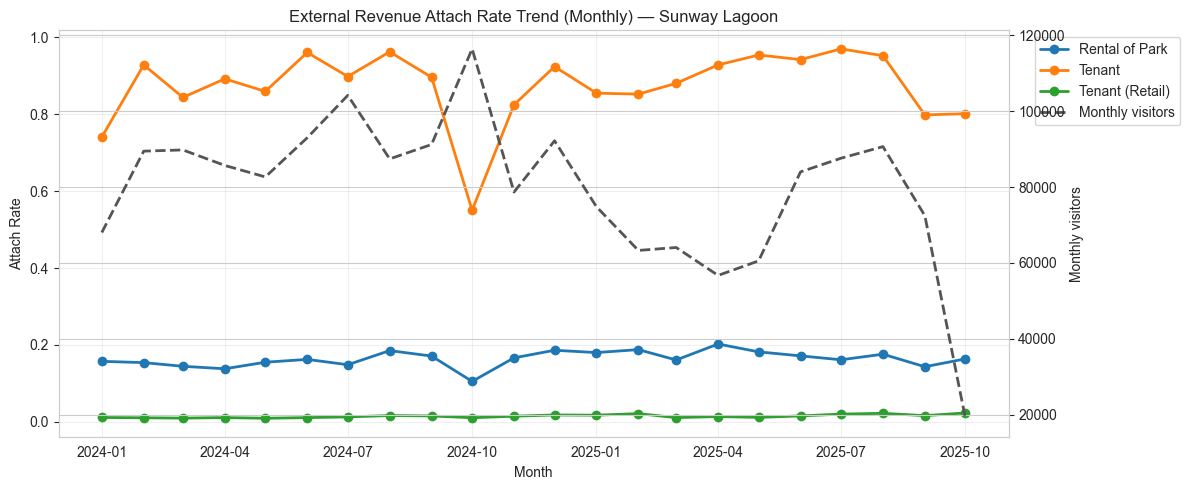

In [216]:
# External Revenue
external_categories = ['Tenant (Retail)', 'Tenant', 'Rental of Park']

monthly_category_txns_internal = monthly_category_txns[
    monthly_category_txns["category_name"].isin(external_categories)
]

def plot_attach_trend(park_name, data):
    sub = data[data["park"] == park_name].sort_values("month")

    fig, ax1 = plt.subplots(figsize=(12, 5))
    for cat, s in sub.groupby("category_name"):
        plt.plot(s["month"], s["attach_rate"], marker="o", linewidth=2, label=cat)

    ax1.set_title(f"External Revenue Attach Rate Trend (Monthly) — {park_name}")
    ax1.set_xlabel("Month")
    ax1.set_ylabel("Attach Rate")
    ax1.grid(True, alpha=0.3)
    
    # Monthly visitors (one value per month)
    monthly_visitors = (
        sub[["month", "visitors"]]
        .drop_duplicates("month")
        .sort_values("month")
    )

    ax2 = ax1.twinx()
    ax2.plot(
        monthly_visitors["month"],
        monthly_visitors["visitors"],
        color="#555555",
        linewidth=2,
        linestyle="--",
        label="Monthly visitors"
    )
    ax2.set_ylabel("Monthly visitors")

    # ✅ Combine legends from both axes
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    plt.show()

plot_attach_trend("Sunway Lagoon", monthly_category_txns_internal)


In [ ]:
# sub category
# lagoon: can look into retail, f&b kiosk, lockers (aug - oct), visitor increase but attach rate decrease
# look at those that has super low attach rate?

fnb_kiosk_comparison = conn.execute("""
SELECT 
    DATE_TRUNC('month', TranDate) AS month,
    Sub_Category,
    SUM(Complete_QTY) AS num_of_items_sold
FROM theme_park_raw
WHERE Category_Name = 'F&B Kiosk'
  AND TranDate >= DATE '2024-09-01'
  AND TranDate <  DATE '2024-11-01'
GROUP BY 
    month, Sub_Category
ORDER BY 
    month, num_of_items_sold;

""").df()

fnb_kiosk_comparison

# Insights: people spend more on buying "OTHERS BEV" which are the exclusive themed beverages during the NOF period, buying the experience. (Tripled)
# NOF is held on Fri, Sat, Sun night after the daytime operation, which I assume there are some people only join NOF (no daytime themepark), hence all other categories drop in attach rate

,month,Sub_Category,num_of_items_sold
0,2024-09-01,COMBO,3.0
1,2024-09-01,OTHERS BEV,1647.0
2,2024-09-01,FOOD,4595.0
3,2024-09-01,CAN,6827.0
4,2024-09-01,MINERAL WATER,10021.0
5,2024-10-01,FOOD,3002.0
6,2024-10-01,OTHERS BEV,5041.0
7,2024-10-01,CAN,5926.0
8,2024-10-01,MINERAL WATER,8606.0


In [187]:
lockers_comparison = conn.execute("""
SELECT 
    DATE_TRUNC('day', TranDate) AS date,
    Category_Name,
    Environment,
    SUM(Complete_QTY) AS num_of_items_sold
FROM theme_park_raw
WHERE Category_Name = 'Lockers'
GROUP BY 
    date, Category_Name, Environment
ORDER BY 
    date, num_of_items_sold;

""").df()

lockers_comparison

,date,Category_Name,Environment,num_of_items_sold
0,2017-01-30,Lockers,2,-1.0
1,2017-01-30,Lockers,1,0.0
2,2017-02-27,Lockers,1,0.0
3,2017-03-30,Lockers,1,0.0
4,2017-04-29,Lockers,1,0.0
...,...,...,...,...
2278,2025-10-07,Lockers,2,13.0
2279,2025-10-08,Lockers,2,89.0
2280,2025-10-08,Lockers,1,284.0
2281,2025-10-09,Lockers,2,65.0


In [ ]:
# lagoon visitor timing (walkin + annual pass)
lagoon_hour_profile = conn.execute("""
with hourly AS (
  SELECT
      CAST(TranDate + INTERVAL '8 hours' AS DATE) AS visit_date,
      EXTRACT('hour' FROM TranDate + INTERVAL '8 hours') AS hour_of_day,
      Environment,
      SUM(Complete_QTY) AS walkin_visitors,
  FROM theme_park_raw
  WHERE TranDate >= '2023-12-31 16:00:00'
    AND TranDate <  '2024-12-31 16:00:00'
    AND LOWER(TRIM(Park)) LIKE 'walk in%'
    
  GROUP BY 1,2,3
  ORDER BY 1,2
)
SELECT
    hour_of_day,
    CASE
        WHEN Environment = 1 THEN 'Sunway Lagoon'
        WHEN Environment = 2 THEN 'Lost World'
    END AS park,
    AVG(walkin_visitors) AS avg_walkin_visitors,
    SUM(walkin_visitors) AS total_walkin_visitors
FROM hourly
GROUP BY 1,2
ORDER BY 1,2
""").df()

lagoon_hour_profile


,hour_of_day,park,avg_walkin_visitors,total_walkin_visitors
0,6,Sunway Lagoon,1.000000,1.0
1,7,Sunway Lagoon,5.000000,15.0
2,8,Sunway Lagoon,4.500000,54.0
3,9,Sunway Lagoon,24.755556,7798.0
4,10,Sunway Lagoon,84.925466,27346.0
5,11,Sunway Lagoon,94.826087,30534.0
6,12,Sunway Lagoon,67.394410,21701.0
7,13,Sunway Lagoon,43.453416,13992.0
8,14,Sunway Lagoon,26.809375,8579.0
9,15,Sunway Lagoon,14.867314,4594.0


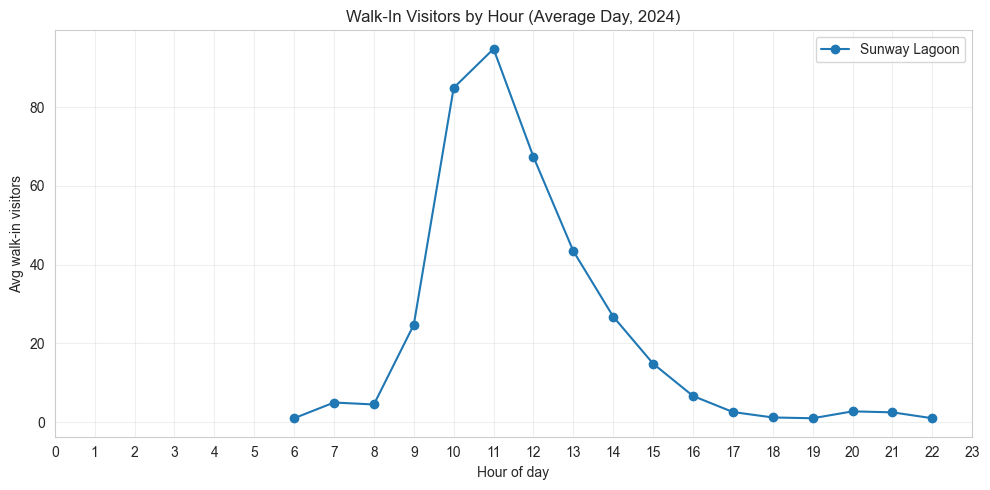

In [229]:
plt.figure(figsize=(10, 5))
for park, sub in walkin_hour_profile.groupby("park"):
    sub = sub.sort_values("hour_of_day")
    plt.plot(sub["hour_of_day"], sub["avg_walkin_visitors"], marker="o", label=park)

plt.title("Walk-In Visitors by Hour (Average Day, 2024)")
plt.xlabel("Hour of day")
plt.ylabel("Avg walk-in visitors")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
